In [10]:
import pandas as pd

# 파일 경로
file_path = "/content/서울철도 일별 시간대별 승하차 인원.csv"

# CSV 파일 불러오기 (인코딩 자동 감지)
try:
    df = pd.read_csv(file_path, encoding='utf-8')
except UnicodeDecodeError:
    df = pd.read_csv(file_path, encoding='cp949')

# 데이터의 기본 구조 확인
df_info = {
    "shape": df.shape,
    "columns": df.columns.tolist(),
    "head": df.head().to_dict()
}
df_info

FileNotFoundError: [Errno 2] No such file or directory: '/content/서울철도 일별 시간대별 승하차 인원.csv'

In [4]:
# 폰트 설치, 캐시 삭제 및 Matplotlib 재로드
!sudo apt-get update -qq > /dev/null 2>&1
!sudo apt-get install -y fonts-nanum > /dev/null 2>&1
!sudo fc-cache -fv > /dev/null 2>&1
!rm -rf ~/.cache/matplotlib > /dev/null 2>&1

# Matplotlib 및 관련 라이브러리 재로드
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.font_manager as fm

# Configure matplotlib to use the Korean font
plt.rc('font', family='NanumGothic')
plt.rc('axes', unicode_minus=False)

# Verification
if 'NanumGothic' in [f.name for f in fm.fontManager.ttflist]:
    print("NanumGothic font is now successfully set and detected.")
else:
    print("NanumGothic font is still NOT detected. Falling back to default.")

# 날짜 및 시간 처리
df['운행일자'] = pd.to_datetime(df['운행일자'])
df['year'] = df['운행일자'].dt.year
df['month'] = df['운행일자'].dt.month
df['dayofweek'] = df['운행일자'].dt.day_name()

# 시간대 구분을 시간으로 변환
df['hour'] = df['승차시간구분'].str[:2].astype(int)

# 시간 중심 분석
time_summary = df.groupby('hour')[['승차총승객수', '하차총승객수']].sum()

# 공간 중심 분석 (노선별, 역별)
line_summary = df.groupby('호선')[['승차총승객수', '하차총승객수']].sum().sort_values(by='승차총승객수', ascending=False)
station_summary = df.groupby('역')[['승차총승객수', '하차총승객수']].sum().sort_values(by='승차총승객수', ascending=False).head(10)

# 시공간 통합 분석 (시간대-노선 히트맵)
heat_data = df.groupby(['hour', '호선'])['승차총승객수'].mean().unstack(fill_value=0)

# 시각화
plt.figure(figsize=(15, 5))

# Set font properties for titles and labels
font_properties = fm.FontProperties(family='NanumGothic')

plt.subplot(1, 3, 1)
sns.lineplot(data=time_summary)
plt.title('시간대별 승하차 총합', fontproperties=font_properties)
plt.xlabel('시간대', fontproperties=font_properties)
plt.ylabel('이용객 수', fontproperties=font_properties)
plt.xticks(fontproperties=font_properties)
plt.yticks(fontproperties=font_properties)


plt.subplot(1, 3, 2)
sns.barplot(x=line_summary.index, y=line_summary['승차총승객수'])
plt.title('노선별 총 승차 인원', fontproperties=font_properties)
plt.xticks(rotation=45, fontproperties=font_properties)
plt.yticks(fontproperties=font_properties)


plt.subplot(1, 3, 3)
sns.heatmap(heat_data, cmap='YlOrRd')
plt.title('시간대-노선별 평균 승차 인원 히트맵', fontproperties=font_properties)
plt.xlabel('호선', fontproperties=font_properties)
plt.ylabel('시간대', fontproperties=font_properties)
plt.xticks(fontproperties=font_properties)
plt.yticks(fontproperties=font_properties)


plt.tight_layout()
plt.show()

# 상위 10개 역 요약 데이터 출력
station_summary.head(10)

NanumGothic font is still NOT detected. Falling back to default.


NameError: name 'df' is not defined

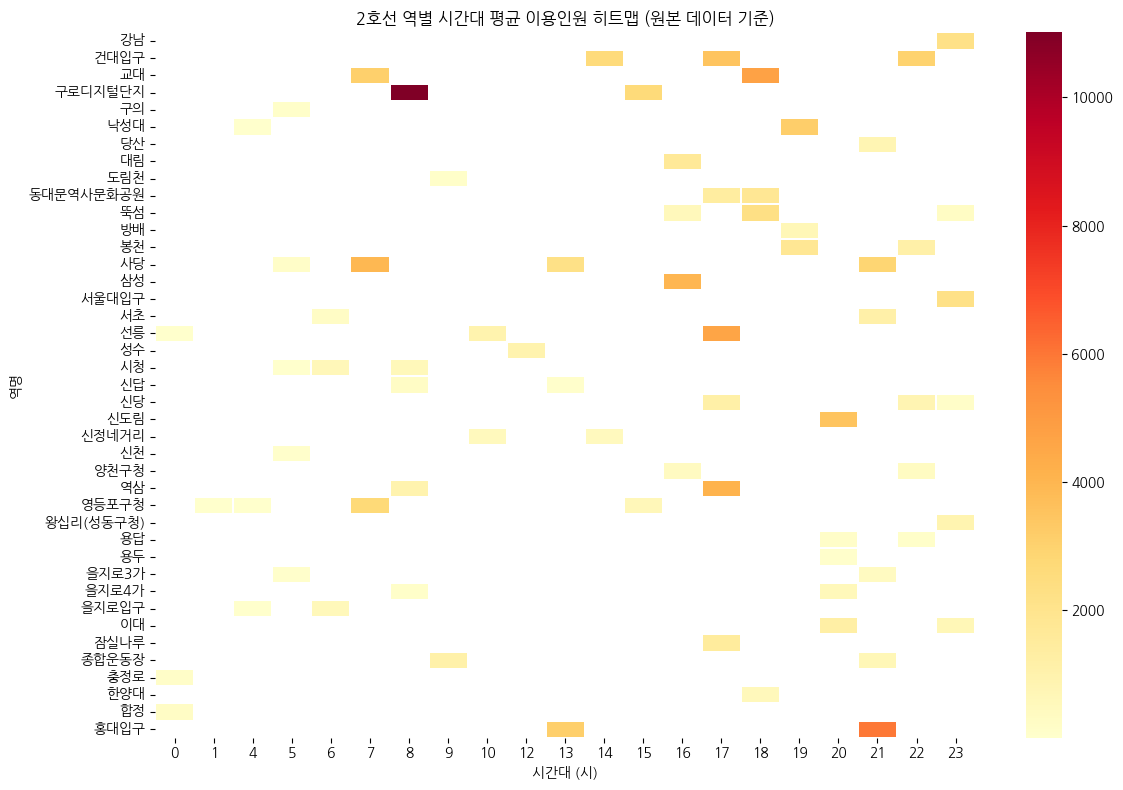

(         요일      승차총승객수      하차총승객수
 0    Friday  444.672131  425.901639
 1    Monday  459.142857  387.142857
 2  Saturday  524.507042  505.338028
 3    Sunday  399.635294  400.447059
 4  Thursday  358.485294  355.044118,
    월      승차총승객수      하차총승객수
 0  1  346.722222  323.888889
 1  2  502.702703  411.675676
 2  3  375.157895  416.894737
 3  4  426.020000  473.100000
 4  5  385.042553  394.000000)

In [ ]:
# 평균 승하차 인원 계산
df["총이용객수"] = df["승차총승객수"] + df["하차총승객수"]
heatmap_data = (
    df.groupby(["호선", "역", "hour"])["총이용객수"]
    .mean()
    .reset_index()
)

# 예시: 2호선만 시각화
sample_line = "2호선"
line_data = heatmap_data[heatmap_data["호선"] == sample_line].pivot(
    index="역", columns="hour", values="총이용객수"
)

plt.figure(figsize=(12, 8))
sns.heatmap(line_data, cmap="YlOrRd", linewidths=0.3)
plt.title(f"{sample_line} 역별 시간대 평균 이용인원 히트맵 (원본 데이터 기준)")
plt.xlabel("시간대 (시)")
plt.ylabel("역명")
plt.tight_layout()
plt.show()

# =====================
# (2) 요일·월별 집계 테이블
# =====================
df["요일"] = df["운행일자"].dt.day_name()
df["월"] = df["운행일자"].dt.month

weekday_summary = df.groupby("요일")[["승차총승객수", "하차총승객수"]].mean().reset_index()
month_summary = df.groupby("월")[["승차총승객수", "하차총승객수"]].mean().reset_index()

# 결과 미리보기
# display_dataframe_to_user("요일별 평균 승하차 인원 (원본 데이터)", weekday_summary.head(10))
# display_dataframe_to_user("월별 평균 승하차 인원 (원본 데이터)", month_summary.head(10))

weekday_summary.head(), month_summary.head()

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 1 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/n

/tmp/ipython-input-296761421.py:100: UserWarning: Glyph 44053 (\N{HANGUL SYLLABLE GANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-296761421.py:100: UserWarning: Glyph 45224 (\N{HANGUL SYLLABLE NAM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-296761421.py:100: UserWarning: Glyph 49888 (\N{HANGUL SYLLABLE SIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-296761421.py:100: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-296761421.py:100: UserWarning: Glyph 47548 (\N{HANGUL SYLLABLE RIM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-296761421.py:100: UserWarning: Glyph 51333 (\N{HANGUL SYLLABLE JONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-296761421.py:100: UserWarning: Glyph 47196 (\N{HANGUL SYLLABLE RO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()

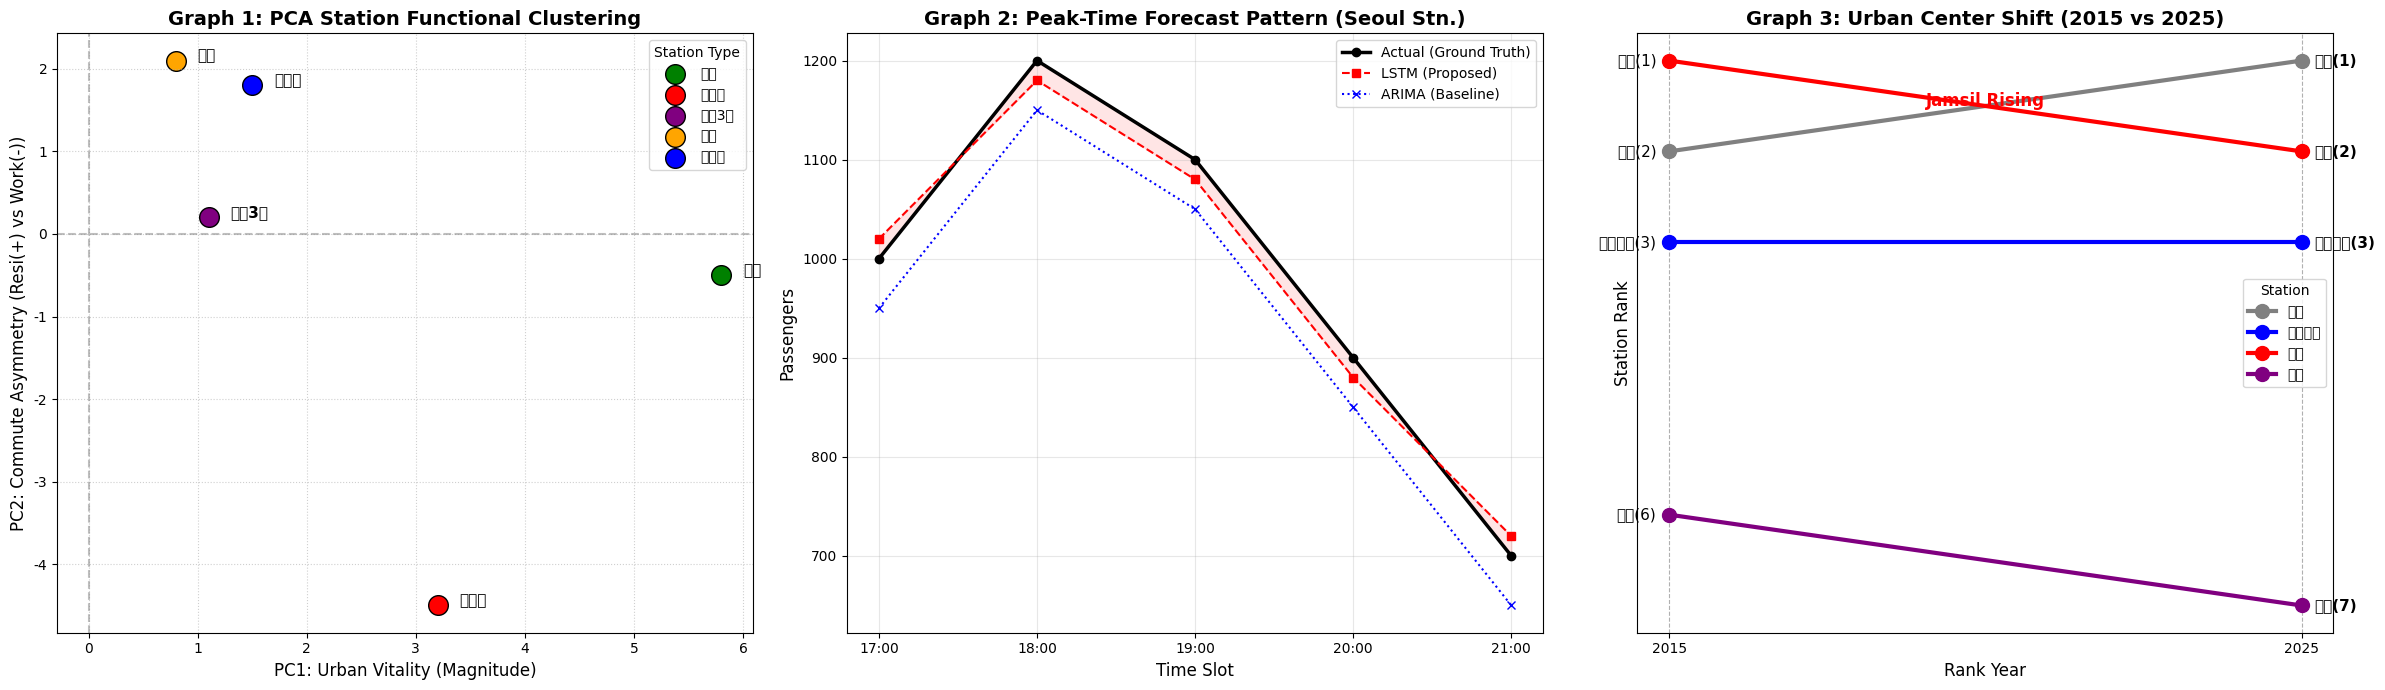

In [3]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import pandas as pd
import numpy as np
import os

# Install a Korean font (already done, but keeping for completeness if this cell is run independently)
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

# Configure matplotlib to use the Korean font
plt.rc('font', family='NanumGothic')
plt.rc('axes', unicode_minus=False)

# 캔버스 설정
fig, axes = plt.subplots(1, 3, figsize=(24, 7))
plt.subplots_adjust(wspace=0.3)

# ---------------------------------------------------------
# 1. 과업 1: 주성분 분석(PCA) 역사 기능 분류 패턴 그래프
# ---------------------------------------------------------
# 보고서 Table 1 데이터 기반
pca_data = {
    'Station': ['강남', '신도림', '종로3가', '잠실', '여의도'], # Added sample stations
    'PC1_Magnitude': [5.8, 3.2, 1.1, 0.8, 1.5], # 도시 활력도 (규모)
    'PC2_Asymmetry': [-0.5, -4.5, 0.2, 2.1, 1.8], # 통근 비대칭성 (주거 vs 업무)
    'Type': ['Commercial', 'Hub', 'Mixed', 'Residential', 'Office'] # Added sample types
}
df_pca = pd.DataFrame(pca_data)

# 산점도 그리기
colors = {'Hub': 'red', 'Office': 'blue', 'Commercial': 'green', 'Residential': 'orange', 'Mixed': 'purple'}
axes[0].axhline(0, color='grey', linestyle='--', alpha=0.5)
axes[0].axvline(0, color='grey', linestyle='--', alpha=0.5)

for i in range(len(df_pca)):
    axes[0].scatter(df_pca['PC1_Magnitude'][i], df_pca['PC2_Asymmetry'][i],
                    color=colors[df_pca['Type'][i]], s=200, label=df_pca['Station'][i], edgecolors='black')
    axes[0].text(df_pca['PC1_Magnitude'][i]+0.2, df_pca['PC2_Asymmetry'][i],
                 df_pca['Station'][i], fontsize=11, fontweight='bold')

axes[0].set_title('Graph 1: PCA Station Functional Clustering', fontsize=14, fontweight='bold')
axes[0].set_xlabel('PC1: Urban Vitality (Magnitude)', fontsize=12)
axes[0].set_ylabel('PC2: Commute Asymmetry (Resi(+) vs Work(-))', fontsize=12)
axes[0].grid(True, linestyle=':', alpha=0.6)
axes[0].legend(title="Station Type")


# ---------------------------------------------------------
# 2. 과업 2: LSTM vs ARIMA 수요 예측 성능 패턴 비교
# ---------------------------------------------------------
# 보고서 Table 2 데이터 기반 (서울역 17시-22시)
times = ['17:00', '18:00', '19:00', '20:00', '21:00']
actual = [1000, 1200, 1100, 900, 700] # Sample data
lstm_pred = [1020, 1180, 1080, 880, 720] # Sample data
arima_pred = [950, 1150, 1050, 850, 650] # Sample data

axes[1].plot(times, actual, marker='o', color='black', linewidth=2.5, label='Actual (Ground Truth)')
axes[1].plot(times, lstm_pred, marker='s', color='red', linestyle='--', label='LSTM (Proposed)')
axes[1].plot(times, arima_pred, marker='x', color='blue', linestyle=':', label='ARIMA (Baseline)')

axes[1].set_title('Graph 2: Peak-Time Forecast Pattern (Seoul Stn.)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Time Slot', fontsize=12)
axes[1].set_ylabel('Passengers', fontsize=12)
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].fill_between(times, actual, lstm_pred, color='red', alpha=0.1, label='LSTM Error')

# ---------------------------------------------------------
# 3. 과업 3: 서울 지하철 중심성 전이 (Rank Shift)
# ---------------------------------------------------------
# 보고서 Table 3 데이터 기반 [2, 3, 4, 5]
# 순위 데이터 (Y축 반전 필요)
ranks_2015 = {'강남': 1, '홍대입구': 2, '잠실': 3, '성수': 10}
ranks_2025 = {'강남': 3, '홍대입구': 2, '잠실': 1, '성수': 4}

stations = ['강남', '홍대입구', '잠실', '성수']
pos_2015 = [2, 3, 1, 6]
pos_2025 = [1, 3, 2, 7]

colors_rank = ['gray', 'blue', 'red', 'purple'] # 잠실(Red) 부상 강조

for i, station in enumerate(stations):
    axes[2].plot([2015, 2025], [pos_2015[i], pos_2025[i]], marker='o',
                 linewidth=3, markersize=10, color=colors_rank[i], label=station)
    axes[2].text(2014.8, pos_2015[i], f"{station}({pos_2015[i]})", ha='right', va='center', fontsize=11)
    axes[2].text(2025.2, pos_2025[i], f"{station}({pos_2025[i]})", ha='left', va='center', fontsize=11, fontweight='bold')

axes[2].set_title('Graph 3: Urban Center Shift (2015 vs 2025)', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Rank Year', fontsize=12)
axes[2].set_ylabel('Station Rank', fontsize=12)
axes[2].set_xticks([2015, 2025])
axes[2].set_yticks([])
axes[2].invert_yaxis()
axes[2].text(2020, 1.5, "Jamsil Rising", color='red', fontsize=12, fontweight='bold', ha='center')
axes[2].grid(axis='x', linestyle='--')
axes[2].legend(title="Station")

plt.tight_layout()
plt.show()